# INPS pensioni: distribuzione regionale dei trattamenti sotto i 1000 euro

Supporto analitico minimo per una prima discussion `Analisi`.

- **Obiettivo**: calcolare l'incidenza dei trattamenti pensionistici nelle classi sotto i 1000 euro per regione.
- **Dati**: mart `mart_pensioni_regione_importo` (INPS 6002).
- **Orizzonte usato qui**: 2024 Q1.
- **Nota**: il dataset conta i trattamenti, non le persone.

In [1]:
import duckdb
import matplotlib.pyplot as plt
from pathlib import Path

def find_workspace_root(start: Path) -> Path:
    for candidate in [start.resolve(), *start.resolve().parents]:
        if (candidate / 'notebooks-lab').exists() and (candidate / 'dataset-incubator').exists():
            return candidate
    raise RuntimeError('Workspace root non trovato')

WORKSPACE_ROOT = find_workspace_root(Path.cwd())
parquet_path = WORKSPACE_ROOT / 'dataset-incubator' / 'out' / 'data' / 'mart' / 'inps_pensioni_2017_2024' / '2024' / 'mart_pensioni_regione_importo.parquet'

if not parquet_path.exists():
    raise FileNotFoundError(f"Mart non trovato: {parquet_path.resolve()}")

con = duckdb.connect()


In [2]:
query = """
SELECT
    regione,
    SUM(CASE WHEN classe_importo IN ('Fino a 499,99', '500,00 - 999,99') THEN numero_pensioni ELSE 0 END) AS total_under_1000,
    SUM(numero_pensioni) AS total_region,
    ROUND(
        100.0 * SUM(CASE WHEN classe_importo IN ('Fino a 499,99', '500,00 - 999,99') THEN numero_pensioni ELSE 0 END) / SUM(numero_pensioni),
        2
    ) AS pct_under_1000
FROM read_parquet(?)
WHERE anno = 2024 AND trimestre = 1
GROUP BY regione
HAVING SUM(numero_pensioni) > 10
ORDER BY pct_under_1000 DESC
"""

df_res = con.execute(query, [str(parquet_path)]).df()
df_res

,regione,total_under_1000,total_region,pct_under_1000
0,Calabria,3917.0,5237.0,74.79
1,Sicilia,9331.0,13117.0,71.14
2,Campania,9042.0,12915.0,70.01
3,Molise,585.0,846.0,69.15
4,Puglia,7429.0,10824.0,68.63
5,Basilicata,1084.0,1593.0,68.05
6,Sardegna,2827.0,4360.0,64.84
7,Umbria,1894.0,3012.0,62.88
8,Abruzzo,2263.0,3786.0,59.77
9,Lazio,7890.0,13417.0,58.81


### Vista rapida

Il grafico rende piu immediato il confronto tra regioni nella quota di trattamenti sotto i 1000 euro.

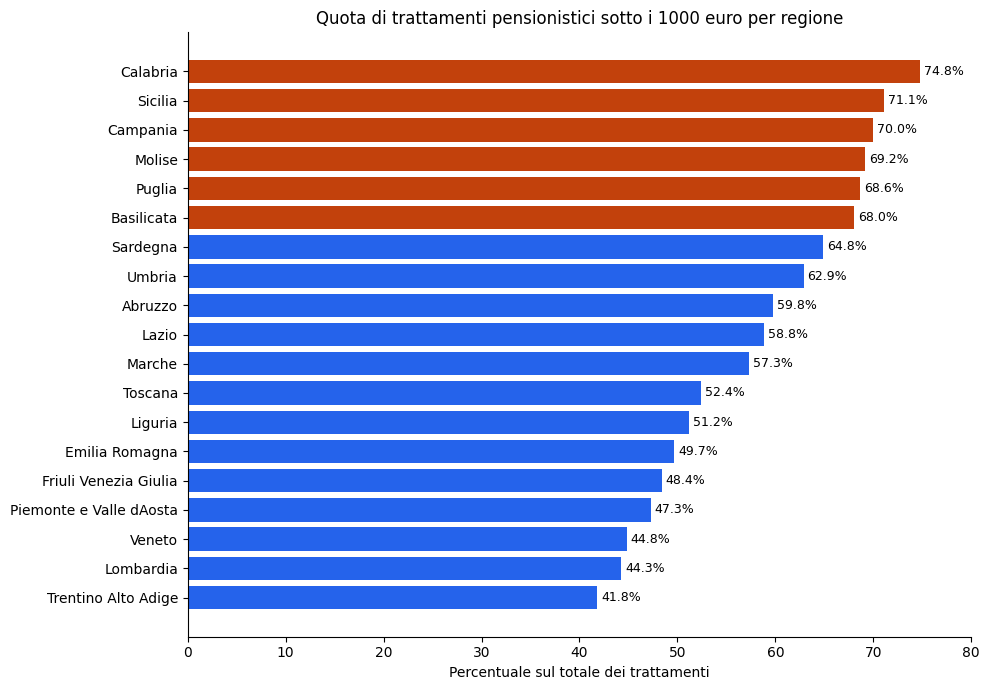

In [3]:
plot_df = df_res.sort_values('pct_under_1000', ascending=True).copy()
colori = ['#c2410c' if value >= 65 else '#2563eb' for value in plot_df['pct_under_1000']]

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(plot_df['regione'], plot_df['pct_under_1000'], color=colori)
ax.set_title('Quota di trattamenti pensionistici sotto i 1000 euro per regione')
ax.set_xlabel('Percentuale sul totale dei trattamenti')
ax.set_ylabel('')
ax.set_xlim(0, max(80, plot_df['pct_under_1000'].max() + 3))

for idx, value in enumerate(plot_df['pct_under_1000']):
    ax.text(value + 0.4, idx, f'{value:.1f}%', va='center', fontsize=9)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [4]:
top_5 = df_res[['regione', 'pct_under_1000']].head(5)
bottom_5 = df_res[['regione', 'pct_under_1000']].tail(5)

print('Top 5 regioni per quota di trattamenti sotto i 1000 euro (2024 Q1)')
display(top_5)

print('Bottom 5 regioni per quota di trattamenti sotto i 1000 euro (2024 Q1)')
display(bottom_5)

Top 5 regioni per quota di trattamenti sotto i 1000 euro (2024 Q1)


,regione,pct_under_1000
0,Calabria,74.79
1,Sicilia,71.14
2,Campania,70.01
3,Molise,69.15
4,Puglia,68.63


Bottom 5 regioni per quota di trattamenti sotto i 1000 euro (2024 Q1)


,regione,pct_under_1000
14,Friuli Venezia Giulia,48.38
15,Piemonte e Valle dAosta,47.26
16,Veneto,44.81
17,Lombardia,44.28
18,Trentino Alto Adige,41.82


### Caveat

- **Trattamenti vs persone**: il dataset conta le prestazioni erogate; una stessa persona puo' riceverne piu' di una.
- **Classi di importo**: la soglia sotto i 1000 euro deriva da classi discrete, non da un importo medio o mediano.
- **Potere d'acquisto**: qui non c'e' alcun confronto con costo della vita o inflazione regionale.
- **Perimetro**: questa e' una prima vista descrittiva regionale, non una misura completa di poverta' pensionistica.